# Precomputed XGBoost Forward Return

Load precomputed LOB features and forward-return labels from `data/orderbook_feature_return_parquet`, infer the feature set from the parquet schema, then run rolling time-series validation with the streaming `XGBoostAdapter`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import numpy as np
import polars as pl
from matplotlib import pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.data import DataSource, DateFrame, Raw, expand_dates
from tools.filters import intraday_time, level_taken, tight_spread, trade_size
from tools.model import XGBoostAdapter
from tools.pipeline import Pipeline
from tools.score import get_unit_pnl, rmse
from tools.search import categorical, int_, loguniform, uniform

In [3]:
def divide_dates(*args):
    dates = []
    for i in range(1, len(args)):
        dates.append(
            expand_dates(
                f"{args[i - 1]}-{args[i]}",
                end_date=False if i < len(args) - 1 else True,
            )
        )
    return dates

In [4]:
# Data
PROD = "ES"
ROLLING_DATES = divide_dates(20260323, 20260410, 20260425, 20260510, 20260524)
TEST_DATES = expand_dates("20260525-20260529")
L2_DEPTH = 5
MODEL_BATCH_SIZE = 200_000
POLARS_ENGINE = "streaming"
FEATURE_RETURN_PATH = str(
    ROOT
    / f"data/orderbook_feature_return_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}_features_return.parquet"
)
REGULAR_HOURS_START = "09:30"
REGULAR_HOURS_END = "16:00"
REGULAR_HOURS_TZ = "America/New_York"

# Forward-return target column already present in FEATURE_RETURN_PATH files.
TARGET = "forward_mid_return_bps"
TEST_PNL_THRESHOLD = 0.2

# XGBoost/search knobs
SEED = 7
SAMPLER = "random"
N_TRIALS = 20
NUM_BOOST_ROUND = 300
EARLY_STOPPING_ROUNDS = 25
SEARCH_SPACE = {
    "objective": categorical(["reg:squarederror"]),
    "eval_metric": categorical(["rmse"]),
    "tree_method": categorical(["hist"]),
    # "device": categorical(["cuda"]),
    "seed": categorical([SEED]),
    "max_depth": int_(2, 6),
    "eta": loguniform(0.01, 0.2),
    "subsample": uniform(0.6, 1.0),
    "colsample_bytree": uniform(0.5, 1.0),
    "min_child_weight": loguniform(1.0, 100.0),
    "lambda": loguniform(1e-3, 100.0),
    "alpha": loguniform(1e-4, 10.0),
}

UNDEF_PRICE = 9_223_372_036_854_775_807
TICKSIZE = 250000000

In [5]:
BOOK_COL_RE = re.compile(r"^(?:bid|ask)_(?:px|sz|ct)_\d+$")
SCHEMA_NON_FEATURE_COLS = {
    "date",
    "nature",
    "ts_event",
    "ts_recv",
    "symbol",
    "instrument_id",
    "row_nr",
    "sequence",
    "publisher_id",
    "trade_px",
    "trade_sz",
    "trade_side",
}

def infer_features_from_schema(schema: pl.Schema, target: str = TARGET) -> list[str]:
    features = []
    for col in schema.names():
        if col == target or col in SCHEMA_NON_FEATURE_COLS or BOOK_COL_RE.match(col):
            continue
        features.append(col)
    if not features:
        raise ValueError("no feature columns inferred from parquet schema")
    return features

FEATURE_SCHEMA_PATH, _ = Raw.resolve_path(ROLLING_DATES[0][0], PROD, FEATURE_RETURN_PATH)
FEATURE_SCHEMA = pl.scan_parquet(FEATURE_SCHEMA_PATH).collect_schema()
# FEATURES = infer_features_from_schema(FEATURE_SCHEMA)
FEATURES = ['weighted_price_sz2']
META_COLS = [col for col in FEATURE_SCHEMA.names() if col not in FEATURES and col != TARGET]
LOAD_COLS = list(dict.fromkeys([*META_COLS, *FEATURES, TARGET]))

FEATURES

['weighted_price_sz2']

In [6]:
VALID_ROWS = (
    (pl.col("bid_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") > pl.col("bid_px_0"))
    & pl.col(TARGET).is_not_null()
    & pl.all_horizontal([pl.col(c).is_finite() for c in FEATURES])
)
REGULAR_HOURS = intraday_time(REGULAR_HOURS_START, REGULAR_HOURS_END, timezone=REGULAR_HOURS_TZ)
TIGHT_SPREAD = tight_spread(TICKSIZE)
VALID_REGULAR_ROWS = VALID_ROWS & REGULAR_HOURS & TIGHT_SPREAD
TRAIN_ROWS = VALID_REGULAR_ROWS & (level_taken() | trade_size(0.3))

REGULAR_HOURS

<Expr ['[([(col("ts_event").dt.convert…'] at 0x7D96D565F140>

In [7]:
def load_feature_return_date(day: str, prod: str = PROD) -> DateFrame:
    return Raw.load_date(day, prod, path=FEATURE_RETURN_PATH, cols=LOAD_COLS)


def regular_loader(dates: list[str]) -> list[DateFrame]:
    return [load_feature_return_date(day) for day in dates]

In [8]:
FEATURE_TEST_SCORE = get_unit_pnl(TEST_PNL_THRESHOLD)
FEATURE_TEST_SCORE_DESCENDING = True

test_date_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

feature_test_states = dict.fromkeys(FEATURES)
feature_test_rows = 0
for x, y_true, ctx in test_date_src.batches(MODEL_BATCH_SIZE):
    feature_test_rows += int(ctx["n"])
    for idx, feature in enumerate(FEATURES):
        feature_test_states[feature] = FEATURE_TEST_SCORE(
            y_true,
            x[:, idx],
            ctx,
            combine_with=feature_test_states[feature],
        )

feature_test_scores = (
    pl.DataFrame(
        [
            {
                "feature": feature,
                "score": getattr(FEATURE_TEST_SCORE, "__name__", "score"),
                "test_score": float(state),
                "score_n": int(getattr(state, "n", 0)),
                "rows": feature_test_rows,
            }
            for feature, state in feature_test_states.items()
            if state is not None
        ]
    )
    .sort("test_score", descending=FEATURE_TEST_SCORE_DESCENDING)
)

feature_test_scores

Loading data: 25.6Mrow [00:05, 5.02Mrow/s]


feature,score,test_score,score_n,rows
str,str,f64,i64,i64
"""weighted_price_sz2""","""unit_pnl_0.2""",0.334344,450,25573459


CV folds can early-stop because they have validation data. The final refit uses the best Optuna params and trains fixed `NUM_BOOST_ROUND` rounds because no validation set is passed to the refit step.

In [9]:
pipeline = Pipeline(
    rolling_dates=ROLLING_DATES,
    test_dates=TEST_DATES,
    adapter=XGBoostAdapter(
        num_boost_round=NUM_BOOST_ROUND,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        batch_size=MODEL_BATCH_SIZE,
        streaming=True,
    ),
    target=TARGET,
    features=FEATURES,
    data_loader=regular_loader,
    search_space=SEARCH_SPACE,
    val_score=rmse,
    train_filters=(TRAIN_ROWS,),
    val_filters=(VALID_REGULAR_ROWS,),
    test_filters=(VALID_REGULAR_ROWS,),
    sampler=SAMPLER,
    n_trials=N_TRIALS,
    cache_arrays=False,
    seed=SEED,
    score_direction="minimize",
    polars_engine=POLARS_ENGINE,
)
pipeline

Pipeline(rolling_dates=[['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'], ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'], ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'], ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22']], test_dates=['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'], adapter=XGBoostAdapter(num_boost_round=300, early_stopping_rounds=25, batch_size=200000, streaming=True, external_memory=False, cache_dir='/tmp/xgb_extmem', cache_prefix='xgb', release_data=True, xgb_dtype=<class 'numpy.float32'>, callbacks=[], pruning_metric=None), target='forward

In [10]:
ROLLING_DATES[-1][:1]

['2026-05-11']

In [11]:
src = DataSource(
    dates=ROLLING_DATES[-1][-1:],
    loader=regular_loader,
    target=TARGET,
    features=FEATURES + ["ts_event", "bid_px_0", "ask_px_0"],
    filters=(VALID_ROWS,),
    polars_engine=POLARS_ENGINE,
)

df = src.frame()[::1000].collect(engine=POLARS_ENGINE)
sprd = 2.0 * (pl.col("ask_px_0") - pl.col("bid_px_0")) / (pl.col("ask_px_0") + pl.col("bid_px_0")) * 1e4
print(src.frame().select(sprd).min().collect(engine=POLARS_ENGINE))
df.head()

shape: (1, 1)
┌──────────┐
│ literal  │
│ ---      │
│ f64      │
╞══════════╡
│ 0.332276 │
└──────────┘


weighted_price_sz2,ts_event,bid_px_0,ask_px_0,forward_mid_return_bps,date,nature
f64,"datetime[ns, UTC]",i64,i64,f64,str,str
0.0,2026-05-17 12:00:04.934361375 UTC,7354000000000,7488000000000,0.0,"""2026-05-22""","""normal"""
0.0,2026-05-21 22:03:07.706784895 UTC,7470000000000,7484000000000,0.0,"""2026-05-22""","""normal"""
-0.083555,2026-05-22 00:00:00.607721795 UTC,7480000000000,7480250000000,-1.721228,"""2026-05-22""","""normal"""
0.0,2026-05-22 00:00:09.032353093 UTC,7479500000000,7479750000000,-1.587646,"""2026-05-22""","""normal"""
0.0,2026-05-22 00:00:26.383719127 UTC,7479750000000,7480000000000,-3.693244,"""2026-05-22""","""normal"""


[[1.]]
weighted_price_sz2 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz2 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.042211           ┆ 1.569304               │
└────────────────────┴────────────────────────┘


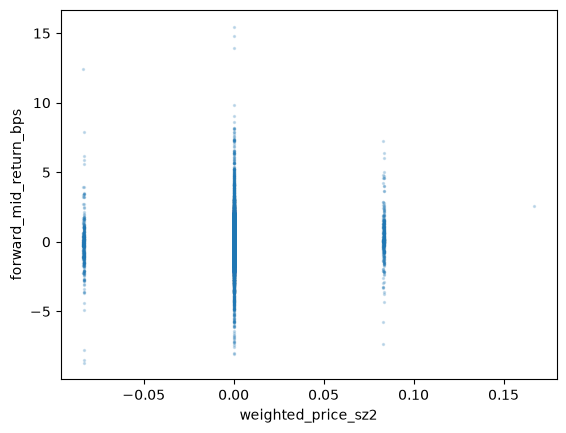

In [12]:
corr = np.zeros((len(FEATURES), len(FEATURES)))
for i, feature_i in enumerate(FEATURES):
    for j, feature_j in enumerate(FEATURES):
        corr[i, j] = df.select(pl.corr(pl.col(feature_i), pl.col(feature_j)))[0].item()
print(corr)

for feature in FEATURES:
    print(feature, df.select(pl.corr(pl.col(feature), pl.col(TARGET)), pl.col(TARGET).std()))
    plt.scatter(df[feature], df[TARGET], s=2, alpha=0.2)
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.show()

In [13]:
train_result = pipeline.train(verbose=2)
train_result

[I 2026-07-02 14:01:15,036] A new study created in memory with name: no-name-9d5f29ac-e396-4100-9aee-2acedab7998d


======== Optuna study created. Launching optimization.
======== running params {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'seed': 7, 'max_depth': 2, 'eta': 0.1034421986607791, 'subsample': 0.7753636925763574, 'colsample_bytree': 0.8617325889154706, 'min_child_weight': 90.36058293737206, 'lambda': 0.49258292359934785, 'alpha': 0.032033347004714594}
======== fold: 0, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'] and val = ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24']


Loading data: 7.08Mrow [00:08, 797krow/s] 
Loading data: 7.08Mrow [00:08, 807krow/s] 
Loading data: 7.08Mrow [00:09, 765krow/s]
Loading data: 7.08Mrow [00:09, 773krow/s]
Loading data: 85.1Mrow [00:21, 4.04Mrow/s]
Loading data: 85.1Mrow [00:26, 3.19Mrow/s]
Loading data: 85.1Mrow [00:22, 3.82Mrow/s]
Loading data: 85.1Mrow [00:52, 1.63Mrow/s]


======== loss = 1.8898191060917133, running average = 1.8898191060917133
======== fold: 1, with train = ['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'] and val = ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08']


Loading data: 10.8Mrow [00:13, 809krow/s] 
Loading data: 10.8Mrow [00:13, 802krow/s] 
Loading data: 10.8Mrow [00:13, 792krow/s] 
Loading data: 10.8Mrow [00:13, 823krow/s] 
Loading data: 69.8Mrow [00:16, 4.31Mrow/s]
Loading data: 69.8Mrow [00:18, 3.82Mrow/s]
Loading data: 69.8Mrow [00:15, 4.43Mrow/s]
Loading data: 69.8Mrow [00:40, 1.70Mrow/s]


...

Loading data: 7.08Mrow [00:08, 849krow/s] 
Loading data: 7.08Mrow [00:08, 831krow/s] 
Loading data: 7.08Mrow [00:08, 803krow/s]
Loading data: 7.08Mrow [00:08, 819krow/s] 
Loading data: 85.1Mrow [00:20, 4.23Mrow/s]
Loading data: 85.1Mrow [00:23, 3.64Mrow/s]
Loading data: 85.1Mrow [00:19, 4.27Mrow/s]
Loading data: 85.1Mrow [00:51, 1.65Mrow/s]
[I 2026-07-02 16:05:34,817] Trial 19 pruned. 


======== loss = 1.8898821473915683, running average = 1.8898821473915683
======== optimization finished, best params extracted. Refitting with best params.


Loading data: 18.2Mrow [00:23, 786krow/s] 
Loading data: 18.2Mrow [00:24, 754krow/s]
Loading data: 18.2Mrow [00:24, 748krow/s] 
Loading data: 18.2Mrow [00:23, 770krow/s] 


======== training done.


{'best_params': {'objective': 'reg:squarederror',
  'eval_metric': 'rmse',
  'tree_method': 'hist',
  'seed': 7,
  'max_depth': 3,
  'eta': 0.15254868329123253,
  'subsample': 0.6853541414319662,
  'colsample_bytree': 0.7260619809088416,
  'min_child_weight': 72.84706174508085,
  'lambda': 0.0013319751967982513,
  'alpha': 0.10063396569448359},
 'best_score': 1.8712881606355702,
 'n_trials': 20,
 'validation_history': [{'trial': 0,
   'fold': 0,
   'val_score': 1.8898191060917133,
   'weighted_score': 1.8898191060917133,
   'n': 85053718,
   'dates': ['2026-04-10',
    '2026-04-13',
    '2026-04-14',
    '2026-04-15',
    '2026-04-16',
    '2026-04-17',
    '2026-04-20',
    '2026-04-21',
    '2026-04-22',
    '2026-04-23',
    '2026-04-24'],
   'natures': ['stress', 'normal'],
   'params': {'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'seed': 7,
    'max_depth': 2,
    'eta': 0.1034421986607791,
    'subsample': 0.7753636925763574,
    'co

In [14]:
best_trial_attrs = pipeline.study.best_trial.user_attrs
xgb_fits = pl.DataFrame(best_trial_attrs.get("xgb_fits", []))
xgb_round_summary = {
    "median": best_trial_attrs.get("xgb_cv_best_num_boost_round_median"),
    "max": best_trial_attrs.get("xgb_cv_best_num_boost_round_max"),
    "fold_rounds": best_trial_attrs.get("xgb_cv_best_num_boost_rounds"),
}
xgb_round_summary, xgb_fits

({'median': 11.0, 'max': 50, 'fold_rounds': [50, 11, 4]},
 shape: (3, 8)
 ┌──────┬──────┬──────────────┬──────────────┬─────────────┬─────────────┬────────────┬─────────────┐
 │ role ┆ fold ┆ train_dates  ┆ val_dates    ┆ best_iterat ┆ best_num_bo ┆ best_score ┆ num_boosted │
 │ ---  ┆ ---  ┆ ---          ┆ ---          ┆ ion         ┆ ost_round   ┆ ---        ┆ _rounds     │
 │ str  ┆ i64  ┆ list[str]    ┆ list[str]    ┆ ---         ┆ ---         ┆ f64        ┆ ---         │
 │      ┆      ┆              ┆              ┆ i64         ┆ i64         ┆            ┆ i64         │
 ╞══════╪══════╪══════════════╪══════════════╪═════════════╪═════════════╪════════════╪═════════════╡
 │ cv   ┆ 0    ┆ ["2026-03-23 ┆ ["2026-04-10 ┆ 49          ┆ 50          ┆ 1.889618   ┆ 75          │
 │      ┆      ┆ ", "2026-03- ┆ ", "2026-04- ┆             ┆             ┆            ┆             │
 │      ┆      ┆ 24", ……      ┆ 13", ……      ┆             ┆             ┆            ┆             │
 │ cv   ┆

In [15]:
rmse_result = pipeline.test(rmse)
rmse_result

Loading data: 25.6Mrow [00:20, 1.25Mrow/s]


{'test_score': 1.6038143118744044,
 'n': 25573459,
 'ctx': {'n': 25573459,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'fold': 'test'},
 'y_pred': array([0.01500322, 0.01500322, 0.01500322, ..., 0.01500322, 0.01500322,
        0.01500322], shape=(25573459,), dtype=float32)}

In [16]:
pnl_result = pipeline.test(get_unit_pnl(0.0))
pnl_result

Loading data: 25.6Mrow [00:10, 2.38Mrow/s]


{'test_score': 0.054691416913260064,
 'n': 25573459,
 'ctx': {'n': 25573459,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'n_active': 25573459,
  'fold': 'test'},
 'y_pred': array([0.01500322, 0.01500322, 0.01500322, ..., 0.01500322, 0.01500322,
        0.01500322], shape=(25573459,), dtype=float32)}

In [27]:
pnl_threshold_result = pipeline.test(get_unit_pnl(0.15))
pnl_threshold_result

Loading data: 25.6Mrow [00:09, 2.82Mrow/s]


{'test_score': 0.7140476088614043,
 'n': 25573459,
 'ctx': {'n': 25573459,
  'dates': ['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'],
  'natures': ['normal'],
  'n_active': 2488,
  'fold': 'test'},
 'y_pred': array([0.01500322, 0.01500322, 0.01500322, ..., 0.01500322, 0.01500322,
        0.01500322], shape=(25573459,), dtype=float32)}

0.011492871 0.024195513


Text(0, 0.5, 'count')

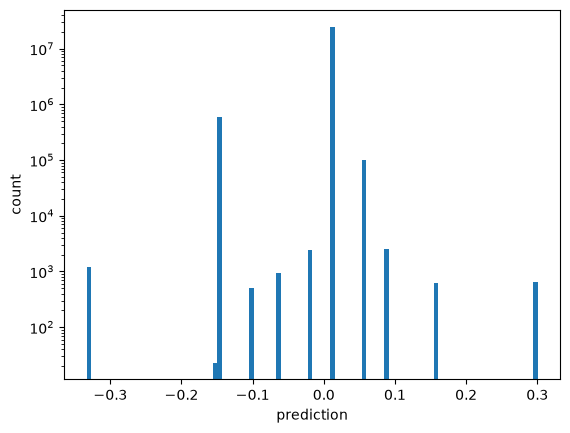

In [18]:
print(np.mean(pnl_threshold_result["y_pred"]), np.std(pnl_threshold_result["y_pred"]))
_ = plt.hist(pnl_threshold_result["y_pred"], bins=100, log=True, density=False)
plt.xlabel("prediction")
plt.ylabel("count")

In [19]:
booster = pipeline.get_model()
gain = booster.get_score(importance_type="gain")
weight = booster.get_score(importance_type="weight")

df_importance = pl.DataFrame(
    [
        {
            "feature": feature,
            "gain": float(gain.get(f"f{idx}", gain.get(feature, 0.0))),
            "weight": float(weight.get(f"f{idx}", weight.get(feature, 0.0))),
        }
        for idx, feature in enumerate(FEATURES)
    ]
).sort("gain", descending=True)

df_importance

feature,gain,weight
str,f64,f64
"""weighted_price_sz2""",1085.912964,1861.0


In [20]:
test_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)
y_true, _ = test_src.labels()
pred_eval = pl.DataFrame({"y_true": y_true, "y_pred": pnl_threshold_result["y_pred"]})
n_pred = pred_eval.height
pred_eval = pred_eval.with_columns(
    (((pl.col("y_pred").rank("average") - 1) * 10 / n_pred).floor().clip(0, 9).cast(pl.Int8)).alias("pred_decile")
)

pred_eval.group_by("pred_decile").agg(
    pl.len().alias("n"),
    pl.col("y_pred").mean().alias("mean_pred"),
    pl.col("y_true").mean().alias("mean_forward_return_bps"),
    (pl.col("y_true") * pl.col("y_pred").sign()).mean().alias("mean_signed_return_bps"),
).sort("pred_decile")

pred_decile,n,mean_pred,mean_forward_return_bps,mean_signed_return_bps
i8,u32,f32,f64,f64
0,592439,-0.143935,-0.034272,0.034272
5,24877581,0.015003,0.053783,0.053783
9,103439,0.05744,0.390002,0.390002


Loading data: 25.6Mrow [00:04, 5.77Mrow/s]


Sampled 25,000 of 25,573,459 streamed test rows for SHAP.


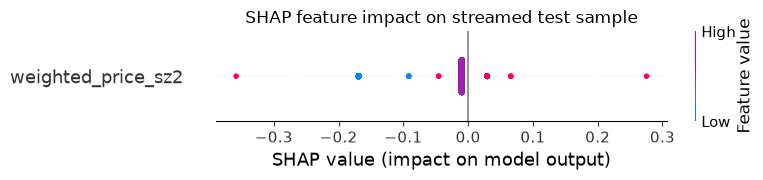

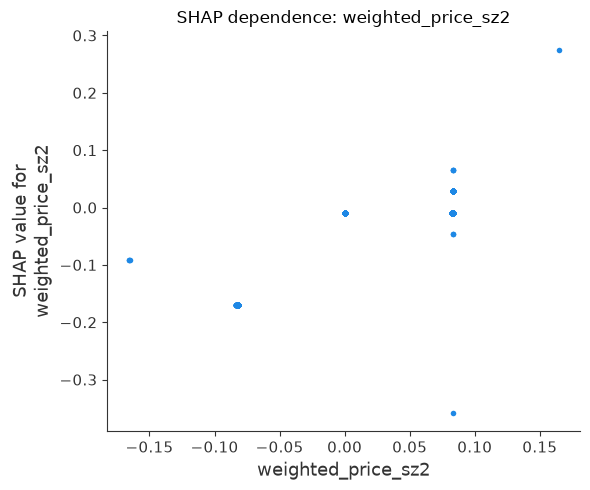

Single feature plot: weighted_price_sz2
Interaction plot: weighted_price_sz2 x weighted_price_sz2 on 5,000 rows


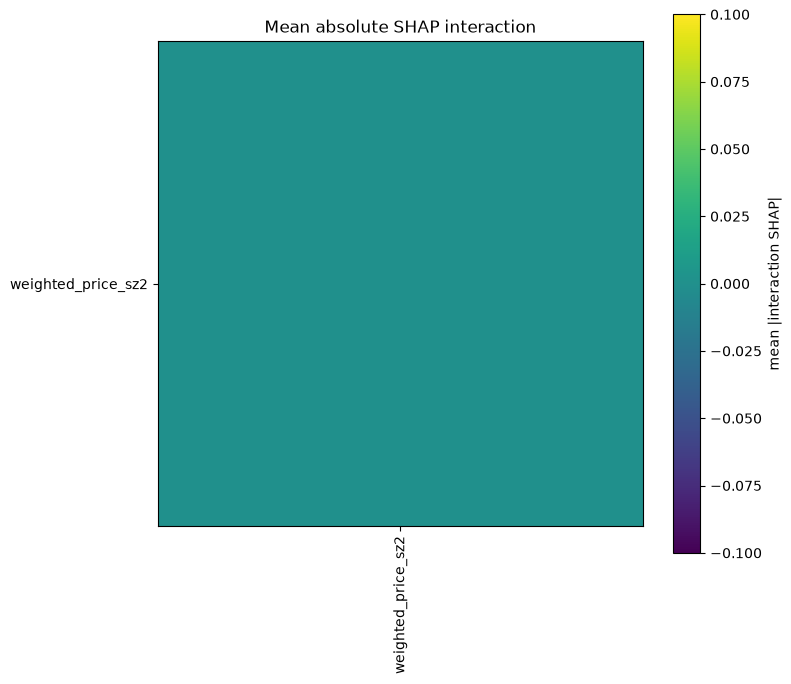

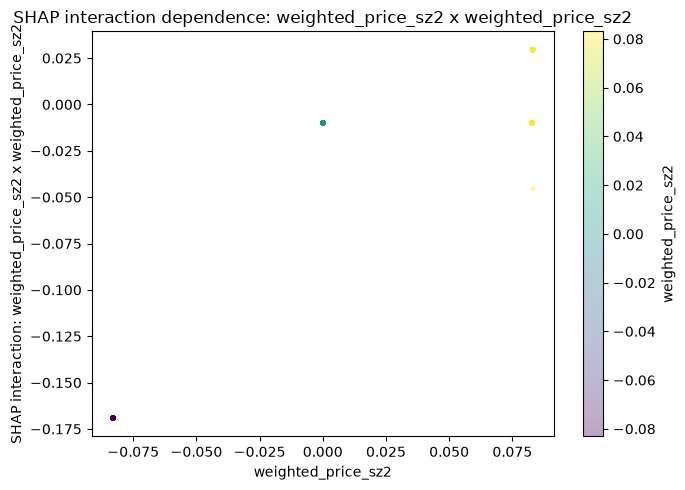

In [21]:
import pandas as pd
import shap

# Keep these bounded; the full test split is too large for SHAP interaction arrays.
SHAP_SAMPLE_ROWS = 25_000
SHAP_INTERACTION_ROWS = 5_000
SHAP_RANDOM_SEED = SEED
SHAP_BATCH_SIZE = MODEL_BATCH_SIZE
SHAP_SINGLE_FEATURE = None  # e.g. "imb_d5"; None chooses highest mean |SHAP|.
SHAP_INTERACTION_PAIR = None  # e.g. ("imb_d5", "imb_d3"); None chooses strongest pair.


def sample_stream_rows(src, max_rows: int, batch_size: int, seed: int):
    total_rows = src.count()
    sample_rows = min(int(max_rows), total_rows)
    if sample_rows <= 0:
        raise ValueError("cannot build SHAP sample from an empty test source")

    rng = np.random.default_rng(seed)
    sample_pos = np.sort(rng.choice(total_rows, size=sample_rows, replace=False))
    x_parts = []
    y_parts = []
    offset = 0
    cursor = 0

    for x, y, _ in src.batches(batch_size):
        n = len(y)
        end = offset + n
        next_cursor = np.searchsorted(sample_pos, end, side="left")
        if next_cursor > cursor:
            local_pos = sample_pos[cursor:next_cursor] - offset
            x_parts.append(np.asarray(x[local_pos], dtype=np.float32))
            y_parts.append(np.asarray(y[local_pos]))
        offset = end
        cursor = next_cursor
        if cursor >= sample_rows:
            break

    if not x_parts:
        raise ValueError("SHAP sampler did not collect any rows")
    return np.vstack(x_parts), np.concatenate(y_parts), total_rows


shap_test_src = DataSource(
    dates=TEST_DATES,
    loader=regular_loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_REGULAR_ROWS,),
    polars_engine=POLARS_ENGINE,
)

X_shap, y_shap, shap_total_rows = sample_stream_rows(
    shap_test_src,
    max_rows=SHAP_SAMPLE_ROWS,
    batch_size=SHAP_BATCH_SIZE,
    seed=SHAP_RANDOM_SEED,
)
X_shap_df = pd.DataFrame(X_shap, columns=FEATURES)
print(f"Sampled {len(X_shap_df):,} of {shap_total_rows:,} streamed test rows for SHAP.")

booster = pipeline.get_model()
shap_explainer = shap.TreeExplainer(booster)
shap_values = shap_explainer.shap_values(X_shap_df)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.asarray(shap_values)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1]
single_feature = SHAP_SINGLE_FEATURE or FEATURES[int(feature_order[0])]
if single_feature not in FEATURES:
    raise ValueError(f"unknown SHAP_SINGLE_FEATURE {single_feature!r}")

shap.summary_plot(shap_values, X_shap_df, max_display=len(FEATURES), show=False)
plt.title("SHAP feature impact on streamed test sample")
plt.tight_layout()
plt.show()

shap.dependence_plot(
    single_feature,
    shap_values,
    X_shap_df,
    interaction_index=None,
    show=False,
)
plt.title(f"SHAP dependence: {single_feature}")
plt.tight_layout()
plt.show()

interaction_rows = min(int(SHAP_INTERACTION_ROWS), len(X_shap_df))
X_interaction_df = X_shap_df.iloc[:interaction_rows].copy()
shap_interaction_values = shap_explainer.shap_interaction_values(X_interaction_df)
if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[0]
shap_interaction_values = np.asarray(shap_interaction_values)
if shap_interaction_values.shape[1:] != (len(FEATURES), len(FEATURES)):
    raise ValueError(
        "unexpected SHAP interaction shape "
        f"{shap_interaction_values.shape}; expected (*, {len(FEATURES)}, {len(FEATURES)})"
    )

mean_abs_interaction = np.abs(shap_interaction_values).mean(axis=0)
mean_abs_interaction_no_diag = mean_abs_interaction.copy()
np.fill_diagonal(mean_abs_interaction_no_diag, 0.0)

if SHAP_INTERACTION_PAIR is None:
    i, j = np.unravel_index(
        int(np.argmax(mean_abs_interaction_no_diag)),
        mean_abs_interaction_no_diag.shape,
    )
    interaction_pair = (FEATURES[int(i)], FEATURES[int(j)])
else:
    interaction_pair = tuple(SHAP_INTERACTION_PAIR)
    if len(interaction_pair) != 2 or any(feature not in FEATURES for feature in interaction_pair):
        raise ValueError(f"unknown SHAP_INTERACTION_PAIR {SHAP_INTERACTION_PAIR!r}")
    i, j = (FEATURES.index(interaction_pair[0]), FEATURES.index(interaction_pair[1]))

print(f"Single feature plot: {single_feature}")
print(f"Interaction plot: {interaction_pair[0]} x {interaction_pair[1]} on {interaction_rows:,} rows")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mean_abs_interaction_no_diag, cmap="viridis")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=90)
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.set_title("Mean absolute SHAP interaction")
fig.colorbar(im, ax=ax, label="mean |interaction SHAP|")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    X_interaction_df[interaction_pair[0]],
    shap_interaction_values[:, i, j],
    c=X_interaction_df[interaction_pair[1]],
    s=7,
    alpha=0.35,
    cmap="viridis",
)
ax.set_xlabel(interaction_pair[0])
ax.set_ylabel(f"SHAP interaction: {interaction_pair[0]} x {interaction_pair[1]}")
ax.set_title(f"SHAP interaction dependence: {interaction_pair[0]} x {interaction_pair[1]}")
fig.colorbar(scatter, ax=ax, label=interaction_pair[1])
fig.tight_layout()
plt.show()